In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [86]:
raw_data = pd.read_csv("../data/clean/merged_data.csv")
print(raw_data.shape)
raw_data.head(10)

(374035, 9)


,brand,model,vehicleType,power,yearOfRegistration,kilometer,fuelType,seller,price
0,volkswagen,golf,NaN,0.0,1993.0,150000.0,gasoline,private,480
1,audi,NaN,coupe,190.0,2011.0,125000.0,diesel,private,18300
2,jeep,grand,suv,163.0,2004.0,125000.0,diesel,private,9800
3,volkswagen,golf,compact,75.0,2001.0,150000.0,gasoline,private,1500
4,skoda,fabia,compact,69.0,2008.0,90000.0,diesel,private,3600
5,bmw,3er,sedan,102.0,1995.0,150000.0,gasoline,private,650
6,peugeot,2reihe,convertible,109.0,2004.0,150000.0,gasoline,private,2200
7,volkswagen,andere,sedan,50.0,1980.0,40000.0,gasoline,private,0
8,ford,cmax,van,125.0,2014.0,30000.0,gasoline,private,14500
9,volkswagen,golf,compact,101.0,1998.0,150000.0,NaN,private,999


In [87]:
print(f"Shape of the dataset: {raw_data.shape}")
print(raw_data.info())

Shape of the dataset: (374035, 9)
<class 'pandas.DataFrame'>
RangeIndex: 374035 entries, 0 to 374034
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brand               374035 non-null  str    
 1   model               353550 non-null  str    
 2   vehicleType         336166 non-null  str    
 3   power               374026 non-null  float64
 4   yearOfRegistration  373966 non-null  float64
 5   kilometer           374014 non-null  float64
 6   fuelType            340647 non-null  str    
 7   seller              374035 non-null  str    
 8   price               374035 non-null  int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 25.7 MB
None


In [88]:
categorical_cols = raw_data.select_dtypes(exclude="number").columns
numerical_cols = raw_data.select_dtypes(include="number").columns
print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

Categorical columns: 5
Numerical columns: 4


In [90]:
raw_data['power'].describe()

count    374026.000000
mean        115.978544
std         191.770656
min           0.000000
25%          70.000000
50%         105.000000
75%         150.000000
max       20000.000000
Name: power, dtype: float64

In [91]:
raw_data['yearOfRegistration'].describe()

count    373966.000000
mean       2004.676607
std          92.572502
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: yearOfRegistration, dtype: float64

In [92]:
raw_data['kilometer'].describe()

count    374014.000000
mean     125298.651171
std       40548.437927
min           0.000000
25%      100000.000000
50%      150000.000000
75%      150000.000000
max      999999.000000
Name: kilometer, dtype: float64

In [93]:

print(raw_data["price"].describe())

count    3.740350e+05
mean     1.736987e+04
std      3.575910e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.990000e+03
75%      7.350000e+03
max      2.147484e+09
Name: price, dtype: float64


In [94]:
raw_data['brand'].value_counts().head(10)

brand
volkswagen      79937
bmw             40483
opel            40250
mercedesbenz    35590
audi            33089
ford            25675
renault         18061
peugeot         11141
fiat             9751
seat             7056
Name: count, dtype: int64

In [95]:
raw_data['fuelType'].value_counts()

fuelType
gasoline    224999
diesel      108335
lpg           5423
hybrid         777
cng            575
electric       330
other          208
Name: count, dtype: int64

In [96]:
raw_data['model'].value_counts().head(10)

model
golf       30133
andere     26400
3er        20567
polo       13134
corsa      12617
astra      10849
passat     10308
a4         10280
cklasse     8775
5er         8546
Name: count, dtype: int64

In [97]:
raw_data['seller'].value_counts()

seller
private    371525
dealer       2510
Name: count, dtype: int64

In [98]:
raw_data['vehicleType'].value_counts()

vehicleType
sedan            96426
compact          80329
station_wagon    67810
van              30348
convertible      22973
coupe            19087
suv              15790
other             3403
Name: count, dtype: int64

In [99]:
# checking for missing values
missing_values = raw_data.isnull().sum()

print("Total missing values in the dataset:", missing_values.sum())
print("Missing values in each column:")
print(f"{missing_values[missing_values > 0]}")
print(f"{(missing_values[missing_values > 0] * 100 / len(raw_data)).round(2)}")

Total missing values in the dataset: 91841
Missing values in each column:
model                 20485
vehicleType           37869
power                     9
yearOfRegistration       69
kilometer                21
fuelType              33388
dtype: int64
model                  5.48
vehicleType           10.12
power                  0.00
yearOfRegistration     0.02
kilometer              0.01
fuelType               8.93
dtype: float64


In [100]:
# checking for full-duplicates rows
duplicate_rows = raw_data[raw_data.duplicated()]
print("Number of duplicate rows:", duplicate_rows.shape[0])


Number of duplicate rows: 62882


In [102]:
print(raw_data["yearOfRegistration"].skew())

72.34539486718862


In [103]:
print(raw_data["power"].describe())

count    374026.000000
mean        115.978544
std         191.770656
min           0.000000
25%          70.000000
50%         105.000000
75%         150.000000
max       20000.000000
Name: power, dtype: float64


In [104]:
print(raw_data["power"].skew())

58.14365830876624


In [105]:
# Data Validity Checks
print("Check for invalid power values (<= 0) or (>= 5000):")
negative_power_count = raw_data[raw_data['power']<=0]['power'].count()
high_power_count = raw_data[raw_data['power']>=5000]['power'].count()
print(f"Invalid power values (<= 0): {negative_power_count}")
print(f"Invalid power values (>= 5000): {high_power_count}")
print(f"Total invalid power values: {(negative_power_count + high_power_count)}")
print(f"percentage of invalid power values: {((negative_power_count + high_power_count) * 100 / len(raw_data)).round(2)}% ")

Check for invalid power values (<= 0) or (>= 5000):
Invalid power values (<= 0): 40820
Invalid power values (>= 5000): 87
Total invalid power values: 40907
percentage of invalid power values: 10.94% 


In [106]:
print("Check for invalid kilometer values (< 0) or (> 300000):")
negative_km_count = raw_data[raw_data['kilometer']<0]['kilometer'].count()
high_km_count = raw_data[raw_data['kilometer']>300000]['kilometer'].count()
print(f"Invalid kilometer values (< 0): {negative_km_count}")
print(f"Invalid kilometer values (> 300000): {high_km_count}")
print(f"Total invalid kilometer values: {(negative_km_count + high_km_count)}")
print(f"percentage of invalid kilometer values: {((negative_km_count + high_km_count) * 100 / len(raw_data)).round(2)}% ")

Check for invalid kilometer values (< 0) or (> 300000):
Invalid kilometer values (< 0): 0
Invalid kilometer values (> 300000): 13
Total invalid kilometer values: 13
percentage of invalid kilometer values: 0.0% 


In [107]:

print("Check for invalid yearOfRegistration values (< 1950):")
before_1950_count = raw_data[raw_data['yearOfRegistration']<1950]["yearOfRegistration"].count()
print(f"Invalid yearOfRegistration values (< 1950): {before_1950_count}")
after_2023_count = raw_data[raw_data['yearOfRegistration']>2023]["yearOfRegistration"].count()
print(f"Invalid yearOfRegistration values (> 2023): {after_2023_count}")
print(f"Total invalid yearOfRegistration values: {before_1950_count + after_2023_count}")
print(f"percentage of invalid yearOfRegistration values: {((before_1950_count + after_2023_count) * 100 / len(raw_data)).round(2)}% ")



Check for invalid yearOfRegistration values (< 1950):
Invalid yearOfRegistration values (< 1950): 290
Invalid yearOfRegistration values (> 2023): 669
Total invalid yearOfRegistration values: 959
percentage of invalid yearOfRegistration values: 0.26% 


In [108]:
raw_data_no_outliers = raw_data[(raw_data['power'] > 0) & (raw_data['power'] < 5000) &
                               (raw_data['kilometer'] >= 0) & (raw_data['kilometer'] <= 300000) &
                               (raw_data['yearOfRegistration'] >= 1950) & (raw_data['yearOfRegistration'] <= 2023)]
print(f"Shape of the dataset after removing invalid values: {raw_data_no_outliers.shape}")

Shape of the dataset after removing invalid values: (332355, 9)


In [109]:
def iqr_outlier_summary(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    iqr_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    iqr_outliers_percentage = round((iqr_outliers.shape[0] * 100 / len(df)), 2)
    print(f"IQR Outliers in {column}: {iqr_outliers.shape[0]} ({iqr_outliers_percentage}%)")
    return iqr_outliers

In [110]:
def z_score_outlier_summary(df, column):
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    z_outliers = df[(z_scores < -3) | (z_scores > 3)]
    z_outliers_percentage = round((z_outliers.shape[0] * 100 / len(df)), 2)
    print(f"Z-Score Outliers in {column}: {z_outliers.shape[0]} ({z_outliers_percentage}%)")
    return z_outliers

In [111]:
iqr_price_outliers = iqr_outlier_summary(raw_data_no_outliers, "price")

IQR Outliers in price: 23387 (7.04%)


In [112]:
z_score_price_outliers = z_score_outlier_summary(raw_data_no_outliers, "price")

Z-Score Outliers in price: 21 (0.01%)


In [113]:
for col in ['kilometer', 'power', 'yearOfRegistration']:
    iqr_outlier_summary(raw_data_no_outliers, col)
    z_score_outlier_summary(raw_data_no_outliers, col)

IQR Outliers in kilometer: 11013 (3.31%)


Z-Score Outliers in kilometer: 4079 (1.23%)
IQR Outliers in power: 12646 (3.8%)
Z-Score Outliers in power: 2868 (0.86%)
IQR Outliers in yearOfRegistration: 5478 (1.65%)
Z-Score Outliers in yearOfRegistration: 3313 (1.0%)


In [114]:
# Skewness
print("Skewness of price column:", raw_data_no_outliers["price"].skew())
print("Skewness of kilometer column:", raw_data_no_outliers["kilometer"].skew())
print("Skewness of power column:", raw_data_no_outliers["power"].skew())
print("Skewness of registration year column:", raw_data_no_outliers["yearOfRegistration"].skew())

Skewness of price column: 558.0148137324101
Skewness of kilometer column: -1.4753049774924785
Skewness of power column: 10.196844037186144
Skewness of registration year column: -0.803226582056281


In [115]:
# Checking Consistency - Schema & Data Types
print("Data Types of Each Column:")
print(raw_data_no_outliers.dtypes)

Data Types of Each Column:
brand                     str
model                     str
vehicleType               str
power                 float64
yearOfRegistration    float64
kilometer             float64
fuelType                  str
seller                    str
price                   int64
dtype: object


In [116]:
raw_data_no_outliers.shape

(332355, 9)

In [ ]:
duplicates = raw_data_no_outliers[raw_data_no_outliers.duplicated(keep=False)]
print(duplicates['brand'].value_counts().head(10)/ len(duplicates) * 100)

brand
volkswagen      7.816642
opel            3.586226
bmw             3.563659
audi            2.607152
mercedesbenz    2.356215
ford            1.773706
renault         1.268523
peugeot         0.761234
fiat            0.590634
seat            0.477501
Name: count, dtype: float64


In [118]:
outlier_indices = iqr_price_outliers.index.union(z_score_price_outliers.index)
clean_data = raw_data_no_outliers.drop(index=outlier_indices, errors="ignore")
clean_data.shape

(308968, 9)

In [ ]:
price_thresholds = [0, 3500, 12000, float("inf")]
clean_data['price_tier'] = pd.cut(clean_data['price'], bins=price_thresholds, labels=['budget', 'mid-range', 'luxury'])
print(clean_data["price_tier"].value_counts())
print((clean_data["price_tier"].value_counts()/len(clean_data["price_tier"]) * 100).round(2), "%")

price_tier
budget       164556
mid-range    111665
luxury        23997
Name: count, dtype: int64
price_tier
budget       54.81
mid-range    37.19
luxury        7.99
Name: count, dtype: float64 %


In [138]:
df_clean = clean_data.copy() 
df_clean['model'] = df_clean.groupby(['brand', 'power'])['model'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "unknown"))
df_clean = df_clean.drop_duplicates()

In [139]:
df_clean.shape

(245630, 10)

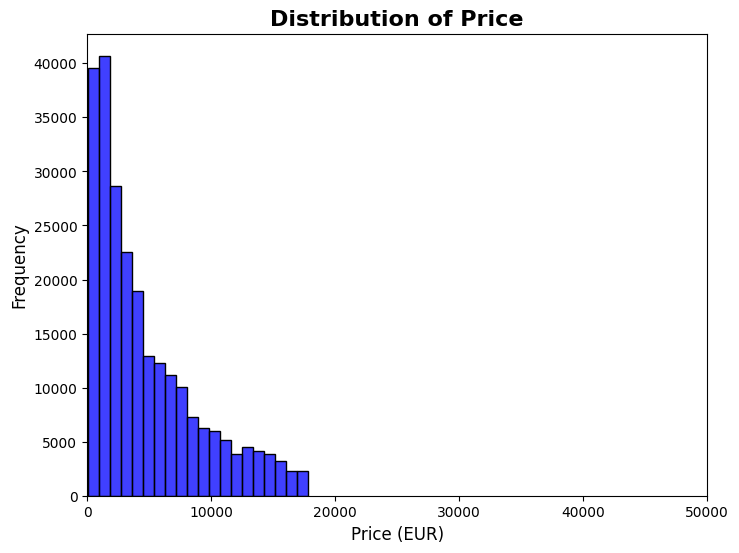

In [140]:
# visualizing the distribution of price tiers
plt.figure(figsize=(8, 6))
sns.histplot(df_clean["price"], bins=20, color="blue")
plt.title("Distribution of Price", fontsize=16, fontweight='bold')
plt.xlabel("Price (EUR)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 50000)      
plt.savefig("../reports/price_distribution.png")
plt.show()

In [141]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 245630 entries, 2 to 374033
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   brand               245630 non-null  str     
 1   model               245630 non-null  str     
 2   vehicleType         226740 non-null  str     
 3   power               245630 non-null  float64 
 4   yearOfRegistration  245630 non-null  float64 
 5   kilometer           245630 non-null  float64 
 6   fuelType            227526 non-null  str     
 7   seller              245630 non-null  str     
 8   price               245630 non-null  int64   
 9   price_tier          245630 non-null  category
dtypes: category(1), float64(3), int64(1), str(5)
memory usage: 19.0 MB


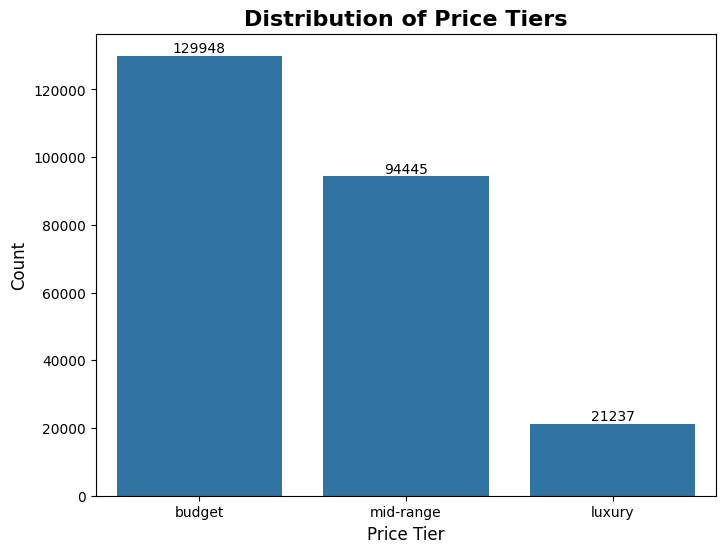

In [142]:
plt.figure(figsize=(8, 6))
sns.countplot(x="price_tier", data=df_clean)
plt.title("Distribution of Price Tiers", fontsize=16, fontweight='bold')
plt.xlabel("Price Tier", fontsize=12)
plt.ylabel("Count", fontsize=12)
for index, value in enumerate(df_clean["price_tier"].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.savefig("../reports/price_tier_distribution.png")
plt.show()

In [143]:
df_clean.to_csv('../data/clean/validated_data.csv', index=False)